# 14_train_evaluate_supervised_ML_models

Run supervised ML training/evaluation across feature combinations, split types, and model choices.

## 1) Environment Setup


In [13]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/AbCode
src_root: /Users/charmainechia/Documents/projects/AbCode/src


## 2) Imports


In [14]:
from pprint import pprint
from project_config.feature_registry import COMBI_ML_FEATURE_SETS
from project_config.variables import address_dict


## 3) Optional Data Segmentation


In [15]:
from abcode.tools.ml.segment_data import run_data_segmentation

# Optional: run segmentation before ML.
segmentation_inputs = {
    'run_segmentation': False,
    'root_key': 'examples', # 'biostream-developability-data',
    'data_subfolder': 'opensource',
    'csv_file': 'opensource.csv',
    'output_csv_file': 'opensource.csv',  # optional override
    'k_folds': 5,
    'mutation_separator': ':',
    'num_mutation_segments_singlemut': 5,
    'max_layer_size_for_multimut_segmentation': [None],
    'min_layer_size_for_multimut_segmentation': 1000,
    'smallest_single_mutant_size': 70,
    'include_mutation_onehot_for_clustering': True,
    'verbose': True,
}

segmentation_result = {'status': 'skipped', 'output_dataset_fname': None}
if segmentation_inputs['run_segmentation']:
    csv_dir = (repo_root / Path(address_dict[segmentation_inputs['root_key']]) / 'expdata' / segmentation_inputs['data_subfolder']).resolve()
    payload = dict(segmentation_inputs)
    payload['csv_dir'] = str(csv_dir)
    segmentation_result = run_data_segmentation(payload)

print(segmentation_result)


{'status': 'skipped', 'output_dataset_fname': None}


## 4) Configure ML Inputs


In [17]:
import abcode.steps.train_evaluate_supervised_ml_models as ml_step
default_user_inputs = ml_step.default_user_inputs
user_inputs = default_user_inputs()

# Edit these for your run
user_inputs['root_key'] = 'examples' # 'biostream-developability-data'
user_inputs['data_fbase'] = user_inputs['root_key']
user_inputs['data_subfolder'] = 'opensource' #
user_inputs['csv_suffix'] = '' #
default_dataset_fname = user_inputs['data_subfolder'] + '.csv'
user_inputs['dataset_fname'] = segmentation_result.get('output_dataset_fname') or default_dataset_fname

# Experimental data parent folder: address_dict[root_key] / "expdata" / data_subfolder
expdata_dir = (repo_root / Path(address_dict[user_inputs['root_key']]) / 'expdata' / user_inputs['data_subfolder']).resolve()
user_inputs['input_filename_prefix'] = user_inputs['data_subfolder'] + '_' # ''
user_inputs['sequence_base'] = None
user_inputs['target_col'] = ['hic_rt_avg', 'sec_%monomer_avg', 'acsins_dLmax_ph7.4_avg', 'tm1_nanodsf_avg']
user_inputs['classification_or_regression'] = 'regression'

# specify splits
user_inputs['split_type_list'] = ['random']
user_inputs['k_folds'] = 5
user_inputs['random_kfold_repeats'] = 1  # >1 enables repeated random k-fold from scratch
user_inputs['random_split_col'] = f'fold_random_{user_inputs["k_folds"]}'
user_inputs['mutres_split_col'] = f'fold_mutres-modulo_{user_inputs["k_folds"]}'
user_inputs['contiguous_split_col'] = f'fold_contiguous_{user_inputs["k_folds"]}'  # optional precomputed column
user_inputs['custom_split_col'] = 'fold_custom'
user_inputs['custom_test_value'] = 1
user_inputs['segment_col'] = 'segment_index_1'  # which segmentation column to use
user_inputs['segment_index_range'] = None

# specify custom dataset name
user_inputs['custom_test_dataset_fname'] = None #
user_inputs['custom_test_data_subfolder'] = user_inputs['data_subfolder']
user_inputs['custom_input_filename_prefix'] = None if user_inputs['custom_test_dataset_fname'] is None else user_inputs['custom_test_dataset_fname'].split('.')[0] # ''

# specify featureset combinations to test
# user_inputs['feature_combinations_dict'] = COMBI_ML_FEATURE_SETS
user_inputs['feature_combinations_dict'] = {
    # 'vh_esm2_seq_embeddings': ['vh_esm2-650m_mean_pooled-33'],
    # 'cdrh3_esm2_seq_embeddings': ['cdrh3_esm2-650m_mean_pooled-33'],
    # 'vh_cdrh3_esm2_seq_embeddings': ['vh_esm2-650m_mean_pooled-33', 'cdrh3_esm2-650m_mean_pooled-33'],
    'vh_esm2_seq_embeddings_cdrh_esm2_pll': ['vh_esm2-650m_mean_pooled-33', 'cdrh3_esm2-650m_PLL-wt', ],
    # 'vh_vl_georgiev_mean_pooled': ['vh_georgiev_mean_pooled', 'vl_georgiev_mean_pooled']
    'vh_esm2_seq_embeddings_cdrh_esm2_pll_georgiev_mean_pooled': ['vh_esm2-650m_mean_pooled-33', 'cdrh3_esm2-650m_PLL-wt', 'vh_georgiev_mean_pooled', 'vl_georgiev_mean_pooled'],


}

# specify models
user_inputs['model_list'] =  ['ridge', 'mlp_pytorch'] # ['ridge']

# run parameters
# hyperparameter tuning (applied from first fold to subsequent folds in each segment)
user_inputs['hyperparameter_mode'] = 'optuna_search' # None # 'preset_search' # 'default', 'ntrain_preset',
user_inputs['tuning_metric'] = 'spearman'
user_inputs['tuning_n_trials'] = 20
user_inputs['summary_source_mode'] = 'all_saved_rows'  # 'run_cache' or 'all_saved_rows'
user_inputs['summary_metric_mode'] = 'average'  # 'average' or 'pooled'

# save parameters
user_inputs['save_trained_models'] = False
user_inputs['save_predictions'] = True
user_inputs['train_full_data_model'] = False
user_inputs['featurecombi_model_pair_to_extract_coefficients_for'] = None # [('onehot', 'ridge')]
user_inputs['show_progress'] = True
pprint(user_inputs)


{'classification_or_regression': 'regression',
 'contiguous_split_col': 'fold_contiguous_5',
 'csv_suffix': '',
 'custom_input_filename_prefix': None,
 'custom_split_col': 'fold_custom',
 'custom_test_data_subfolder': 'opensource',
 'custom_test_dataset_fname': None,
 'custom_test_value': 1,
 'data_fbase': 'examples',
 'data_subfolder': 'opensource',
 'dataset_fname': 'opensource.csv',
 'feature_combinations_dict': {'vh_esm2_seq_embeddings_cdrh_esm2_pll': ['vh_esm2-650m_mean_pooled-33',
                                                                        'cdrh3_esm2-650m_PLL-wt'],
                               'vh_esm2_seq_embeddings_cdrh_esm2_pll_georgiev_mean_pooled': ['vh_esm2-650m_mean_pooled-33',
                                                                                             'cdrh3_esm2-650m_PLL-wt',
                                                                                             'vh_georgiev_mean_pooled',
                                              

## 5) Run Training And Evaluation


In [19]:
import importlib

import abcode.tools.ml.model_registry as model_registry
import abcode.tools.ml.hyperparameter_tuning as hyperparameter_tuning
import abcode.tools.ml.workflow as workflow
import abcode.steps.train_evaluate_supervised_ml_models as ml_step

importlib.reload(model_registry)
importlib.reload(hyperparameter_tuning)
importlib.reload(workflow)
ml_step = importlib.reload(ml_step)

result = ml_step.train_evaluate_supervised_ml_models(user_inputs)
pprint(result)


[I 2026-04-06 10:41:37,222] A new study created in memory with name: no-name-50ef261e-4b01-44e9-ad2d-4dfec4fc72bf
[I 2026-04-06 10:41:37,257] Trial 0 finished with value: 0.6761234851979449 and parameters: {'reg_strength': 0.7459343285726545}. Best is trial 0 with value: 0.6761234851979449.
[I 2026-04-06 10:41:37,265] Trial 1 finished with value: 0.5786582839369925 and parameters: {'reg_strength': 566.9849511478844}. Best is trial 0 with value: 0.6761234851979449.
[I 2026-04-06 10:41:37,272] Trial 2 finished with value: 0.6423297155030209 and parameters: {'reg_strength': 45.70563099801449}. Best is trial 0 with value: 0.6761234851979449.
[I 2026-04-06 10:41:37,281] Trial 3 finished with value: 0.676646344280689 and parameters: {'reg_strength': 9.846738873614559}. Best is trial 3 with value: 0.676646344280689.
[I 2026-04-06 10:41:37,291] Trial 4 finished with value: 0.5402868296196746 and parameters: {'reg_strength': 0.06026889128682511}. Best is trial 3 with value: 0.676646344280689.
[

[row-filter] context=target_col=hic_rt_avg | split_type=random | feature_combi_name=vh_esm2_seq_embeddings_cdrh_esm2_pll | dropped_rows=16 | remaining_rows=651
[eval-start] target_col=hic_rt_avg | split_type=random | feature_combi_name=vh_esm2_seq_embeddings_cdrh_esm2_pll | model_name=ridge
[tuning-trial] model=ridge | metric=spearman | trial=1/20 | value=0.676123 | best=0.676123
[tuning-trial] model=ridge | metric=spearman | trial=2/20 | value=0.578658 | best=0.676123
[tuning-trial] model=ridge | metric=spearman | trial=3/20 | value=0.642330 | best=0.676123
[tuning-trial] model=ridge | metric=spearman | trial=4/20 | value=0.676646 | best=0.676646
[tuning-trial] model=ridge | metric=spearman | trial=5/20 | value=0.540287 | best=0.676646
[tuning-trial] model=ridge | metric=spearman | trial=6/20 | value=0.540287 | best=0.676646
[tuning-trial] model=ridge | metric=spearman | trial=7/20 | value=0.480532 | best=0.676646
[tuning-trial] model=ridge | metric=spearman | trial=8/20 | value=0.599

[I 2026-04-06 10:41:37,417] Trial 18 finished with value: 0.6493829778233065 and parameters: {'reg_strength': 34.637207334192986}. Best is trial 14 with value: 0.6877170850632858.
[I 2026-04-06 10:41:37,427] Trial 19 finished with value: 0.6826432178419607 and parameters: {'reg_strength': 4.29497140732572}. Best is trial 14 with value: 0.6877170850632858.
[I 2026-04-06 10:41:37,497] A new study created in memory with name: no-name-bf245318-af89-485b-9ece-145738a0c4e9


[tuning-trial] model=ridge | metric=spearman | trial=19/20 | value=0.649383 | best=0.687717
[tuning-trial] model=ridge | metric=spearman | trial=20/20 | value=0.682643 | best=0.687717
[tuning-complete] model=ridge | metric=spearman | direction=maximize | best_value=0.687717 | n_trials=20
[tuning-selected] model=ridge | selected_hyperparameters={'max_iter': 1000, 'alpha': 2.555151394803624}
[fold-result] split_id=0 | split_name=random_fold_0 | split_type=random | eval_group=all_data | data_size_n=651 | segments_included= | n_train=520 | n_test=131
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.4863        0.8752   0.7515     4.2882          0.6444         0.9007    0.8024      3.8283
[eval-start] target_col=hic_rt_avg | split_type=random | feature_combi_name=vh_esm2_seq_embeddings_cdrh_esm2_pll | model_name=ridge
[fold-result] split_id=1 | split_name=random_fold_1 | split_type=random | eval_group=all_data | data_size_n=651

[I 2026-04-06 10:41:38,240] Trial 0 finished with value: 0.6245685125800019 and parameters: {'hidden_size': 96, 'learning_rate': 0.004123206532618728, 'batch_size': 8}. Best is trial 0 with value: 0.6245685125800019.


...

[tuning-trial] model=mlp_pytorch | metric=spearman | trial=18/20 | value=0.349057 | best=0.351920


[I 2026-04-06 10:45:29,026] Trial 18 finished with value: 0.34234087359970927 and parameters: {'hidden_size': 192, 'learning_rate': 0.0009171850846175479, 'batch_size': 16}. Best is trial 10 with value: 0.3519198869150589.


[tuning-trial] model=mlp_pytorch | metric=spearman | trial=19/20 | value=0.342341 | best=0.351920


[I 2026-04-06 10:45:30,796] Trial 19 finished with value: 0.3379650061533791 and parameters: {'hidden_size': 64, 'learning_rate': 0.0004433813292687663, 'batch_size': 32}. Best is trial 10 with value: 0.3519198869150589.


[tuning-trial] model=mlp_pytorch | metric=spearman | trial=20/20 | value=0.337965 | best=0.351920
[tuning-complete] model=mlp_pytorch | metric=spearman | direction=maximize | best_value=0.351920 | n_trials=20
[tuning-selected] model=mlp_pytorch | selected_hyperparameters={'n_layers': 2, 'hidden_size': 256, 'batch_size': 64, 'learning_rate': 0.0006370432544336975, 'max_epochs': 400, 'patience': 15, 'min_delta': 1e-05, 'validation_split': 0.2, 'random_state': 42, 'device': 'cpu'}
[fold-result] split_id=0 | split_name=random_fold_0 | split_type=random | eval_group=all_data | data_size_n=510 | segments_included= | n_train=408 | n_test=102
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
         0.429        0.3978   0.1339     4.6683          0.4909         0.5643    0.3124      3.7082
[eval-start] target_col=tm1_nanodsf_avg | split_type=random | feature_combi_name=vh_esm2_seq_embeddings_cdrh_esm2_pll_georgiev_mean_pooled | model_name=m

## 6) Visualize ML Results


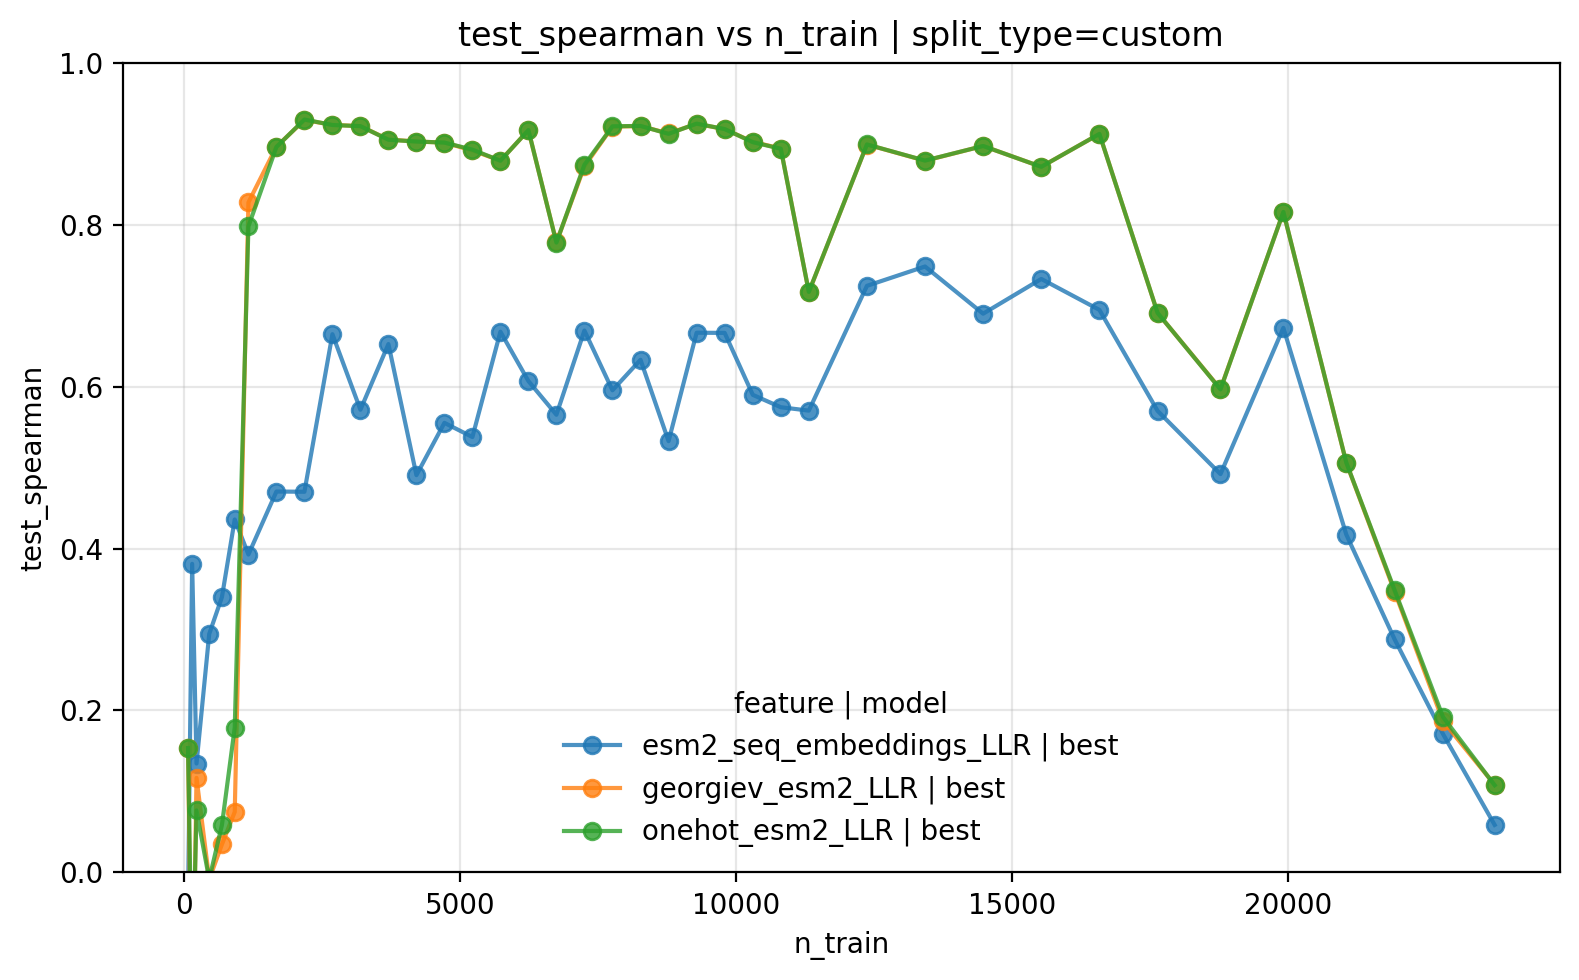

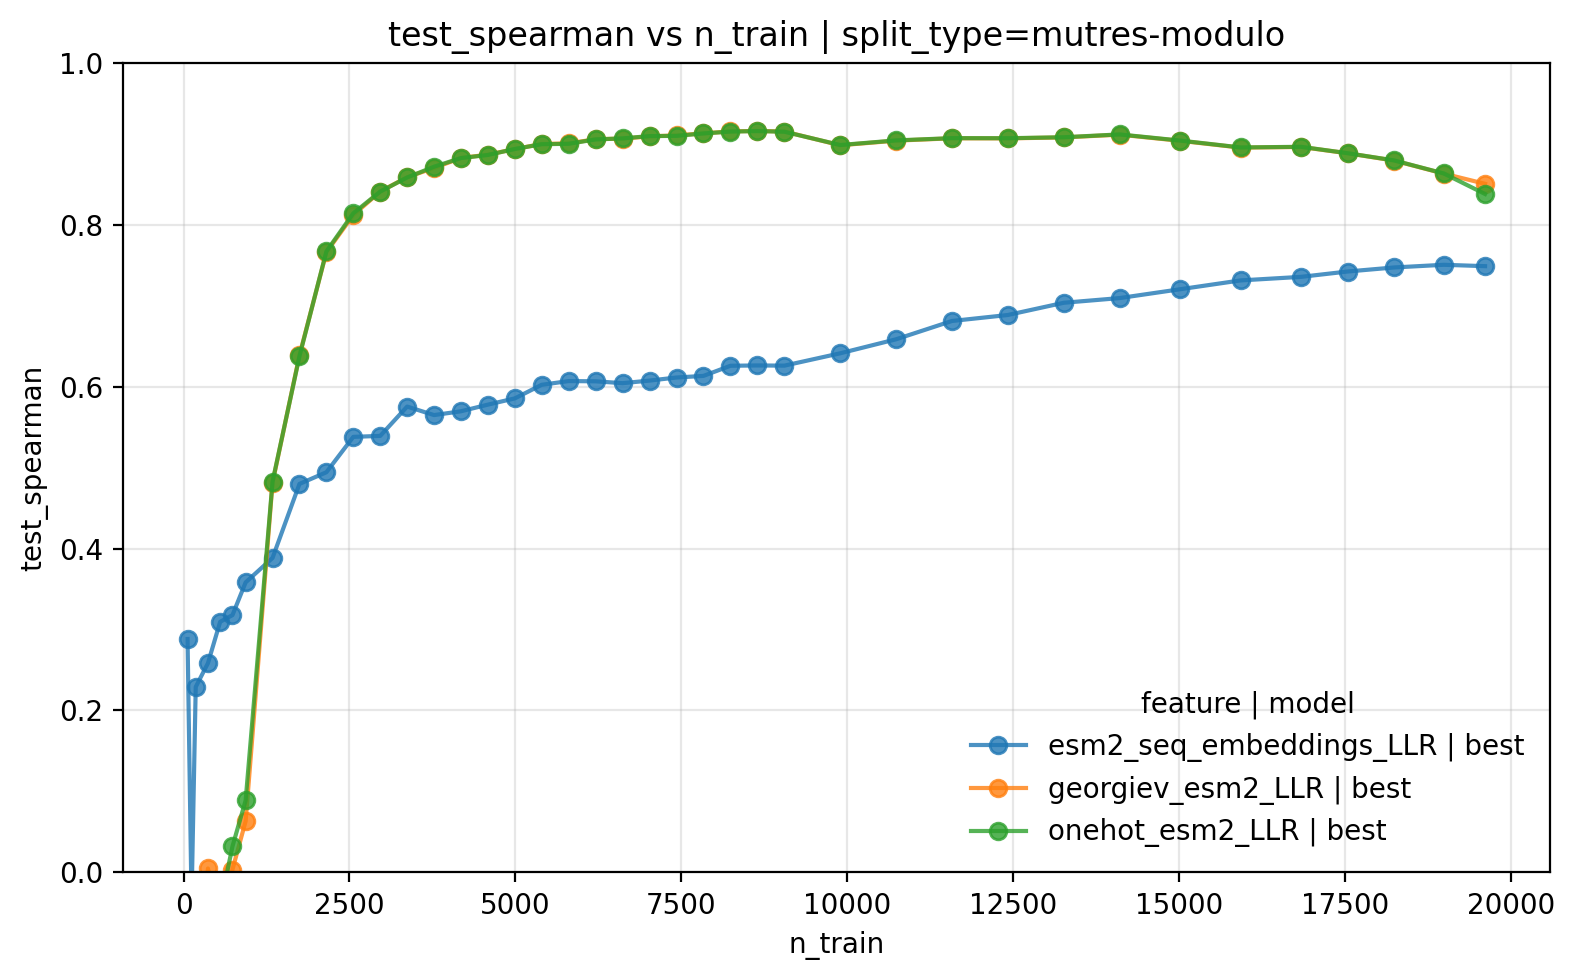

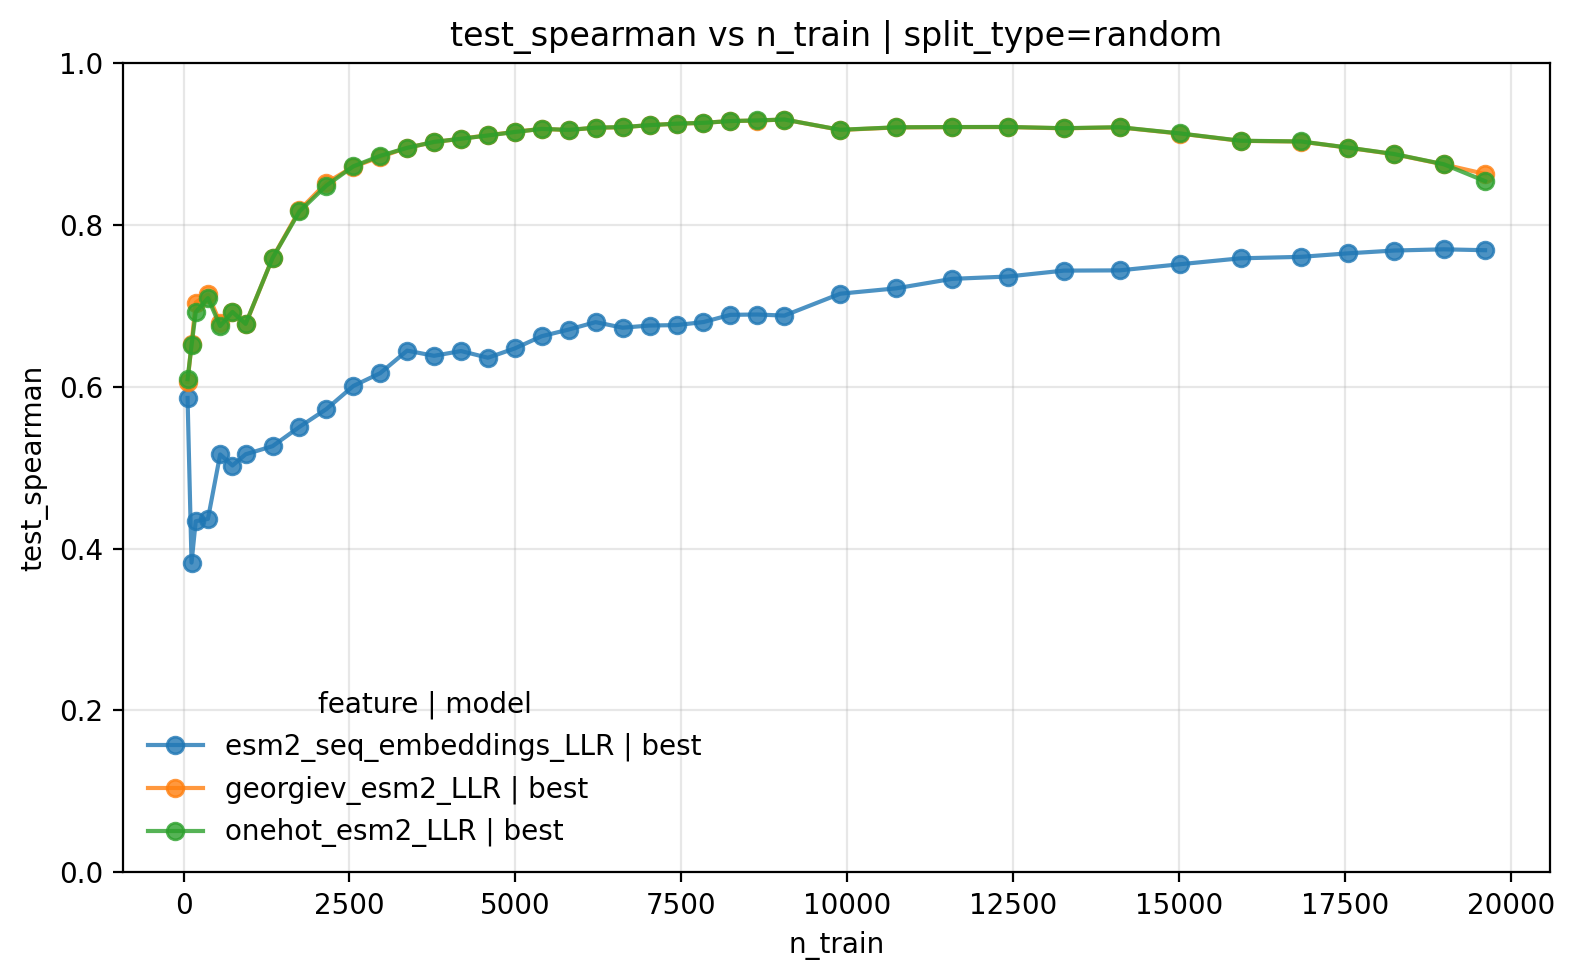

{'figure_paths': ['/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_custom_best.png',
                  '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_mutres-modulo_best.png',
                  '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_random_best.png'],
 'metric_col_list': ['test_spearman'],
 'n_filtered_rows': 726,
 'n_plot_rows_total': 363,
 'n_summary_rows': 726,
 'plotted_pairs': [{'metric_col': 'test_spearman',
                    'n_lines': 3,
                    'n_rows': 117,
                    'split_type': 'custom'},
                   {'metric_col': 'test_spearman',
                    'n_lines': 3,
                    'n_rows': 123,
                    'split_type': 'mutres-modulo'},
                  

In [8]:
from pprint import pprint

import importlib

import abcode.steps.visualize_ml_results as ml_viz_step
ml_viz_step = importlib.reload(ml_viz_step)

visualize_ml_results = ml_viz_step.visualize_ml_results
default_viz_inputs = ml_viz_step.default_user_inputs

viz_inputs = default_viz_inputs()
viz_inputs['data_fbase'] = user_inputs.get('data_fbase', 'examples')
viz_inputs['data_subfolder'] = user_inputs.get('data_subfolder', '')
viz_inputs['metrics_summary_fname'] = f"{user_inputs['classification_or_regression']}_metrics_summary{user_inputs.get('csv_suffix', '')}.csv"
viz_inputs['model_name_list'] = ['best'] # ['xgboost', 'ridge']
viz_inputs['metric_col'] = ['test_spearman']  # string or list
viz_inputs['target_col_list'] = user_inputs.get('target_col', []) if isinstance(user_inputs.get('target_col', []), list) else [user_inputs.get('target_col')]
viz_inputs['split_type_list'] = []  # [] -> iterate all split types in summary CSV
viz_inputs['feature_label_list'] = list(user_inputs['feature_combinations_dict'].keys())
viz_inputs['show_model_type'] = False  # True -> marker shape based on model type
viz_inputs['save_figure'] = True
viz_inputs['show_figure'] = True
viz_inputs['figure_output_dir'] = ''  # default: summary csv folder
viz_inputs['figure_fname'] = ''       # default auto name
viz_inputs['x_limits'] = [0, None]  # e.g. [0, 10000]; None/[] uses matplotlib defaults
viz_inputs['y_limits'] = [0, 1]      # e.g. [0.0, 1.0]; None/[] uses matplotlib defaults

# Optional override:
viz_inputs['metrics_summary_csv_path'] = '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/regression_metrics_summary_merged-0-1.csv'

viz_result = visualize_ml_results(viz_inputs)
pprint(viz_result)
